# Round 4 — Data Exploration & Sandbox Diagnostics

Round-4 dataset: VELVETFRUIT_EXTRACT (underlying), HYDROGEL_PACK (independent), and 10 VEV vouchers (strikes 4000–6500). 3 days × 10k ticks each.

**This notebook supports two workflows:**
1. Inspecting the raw round-4 dataset (price/trade CSVs).
2. Diagnosing a real Prosperity sandbox submission log dropped at the repo root (e.g. `489790/`).

Use the per-asset PnL attribution + regime-timeline cells to understand where a strategy bleeds and when the spot regime gate fires.

In [1]:
import json
import math
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path('..').resolve()
DATA = REPO / 'backtester' / 'datasets' / 'round4'
DAYS = [1, 2, 3]
UNDERLYING = 'VELVETFRUIT_EXTRACT'
STRIKES = {f'VEV_{k}': k for k in [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]}
LIVE_STRIKES = ['VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500']

## 1. Load round-4 dataset (price + trade CSVs)

In [2]:
prices = pd.concat(
    [pd.read_csv(DATA / f'prices_round_4_day_{d}.csv', sep=';') for d in DAYS],
    ignore_index=True,
)
trades = pd.concat(
    [pd.read_csv(DATA / f'trades_round_4_day_{d}.csv', sep=';') for d in DAYS],
    ignore_index=True,
)
print('prices rows:', len(prices), '  trades rows:', len(trades))
prices.groupby(['day', 'product'])['mid_price'].agg(['first', 'last', 'mean', 'std']).round(2).head(15)

prices rows: 360000   trades rows: 4281


first     last     mean    std
day product                                              
1   HYDROGEL_PACK         9958.0  10015.0  9992.06  37.61
    VELVETFRUIT_EXTRACT   5245.0   5265.5  5248.39  14.61
    VEV_4000              1245.0   1265.5  1248.41  14.63
    VEV_4500               745.0    765.5   748.41  14.63
    VEV_5000               251.0    268.5   253.26  13.58
    VEV_5100               165.0    177.5   164.98  11.94
    VEV_5200                95.5    102.5    95.13   8.66
    VEV_5300                47.0     52.0    46.91   5.47
    VEV_5400                16.5     17.0    15.65   2.68
    VEV_5500                 7.5      6.5     6.57   1.33
    VEV_6000                 0.5      0.5     0.50   0.00
    VEV_6500                 0.5      0.5     0.50   0.00
2   HYDROGEL_PACK        10011.0  10010.0  9989.40  31.62
    VELVETFRUIT_EXTRACT   5267.5   5295.5  5255.39  16.99
    VEV_4000              1267.5   1295.0  1255.40  17.00

## 2. Underlying spot path across all 3 days

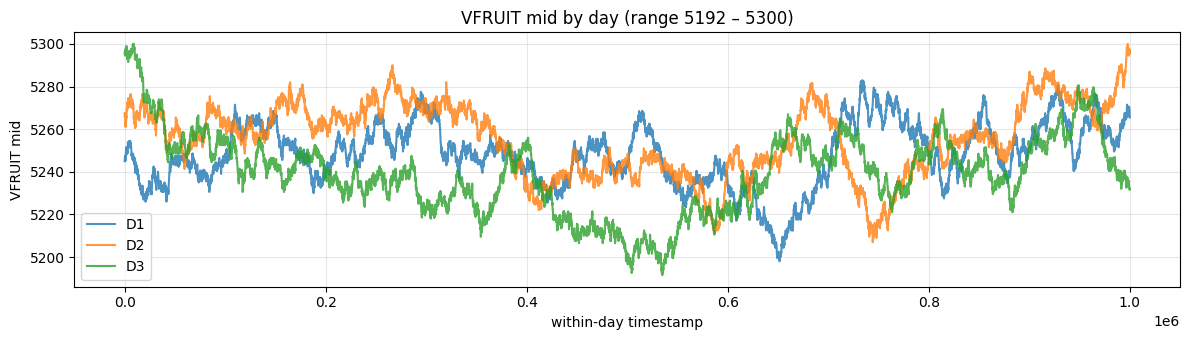

,first,last,mean,std
day,,,,
1,5245.0,5265.5,5248.39,14.61
2,5267.5,5295.5,5255.39,16.99
3,5295.5,5232.0,5239.16,18.60


In [3]:
spot = prices[prices['product'] == UNDERLYING].copy()
spot['ts_global'] = (spot['day'] - 1) * 1_000_000 + spot['timestamp']
fig, ax = plt.subplots(figsize=(12, 3.5))
for d in DAYS:
    sub = spot[spot['day'] == d]
    ax.plot(sub['timestamp'], sub['mid_price'], label=f'D{d}', alpha=0.8)
ax.set_xlabel('within-day timestamp')
ax.set_ylabel('VFRUIT mid')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title(f'VFRUIT mid by day (range {spot.mid_price.min():.0f} – {spot.mid_price.max():.0f})')
plt.tight_layout(); plt.show()
spot.groupby('day')['mid_price'].agg(['first', 'last', 'mean', 'std']).round(2)

## 3. Voucher mid + computed time value (TV = mid - max(0, S-K))

In [4]:
spot_lookup = spot.set_index(['day', 'timestamp'])['mid_price']
vev = prices[prices['product'].str.startswith('VEV_')].copy()
vev['strike'] = vev['product'].map(STRIKES)
vev = vev.merge(spot_lookup.rename('spot'), left_on=['day', 'timestamp'], right_index=True, how='left')
vev['intrinsic'] = (vev['spot'] - vev['strike']).clip(lower=0)
vev['tv'] = vev['mid_price'] - vev['intrinsic']
vev.groupby('product')['tv'].agg(['mean', 'std', 'min', 'max']).round(2)

,mean,std,min,max
product,,,,
VEV_4000,0.01,0.86,-7.0,7.0
VEV_4500,0.01,0.77,-6.0,5.5
VEV_5000,3.50,1.52,-1.5,10.0
VEV_5100,13.21,3.80,3.0,27.0
VEV_5200,41.33,7.51,21.0,67.5
VEV_5300,41.18,9.14,18.0,61.0
VEV_5400,12.63,4.15,3.5,23.0
VEV_5500,4.71,2.21,0.5,10.0
VEV_6000,0.50,0.00,0.5,0.5


## 4. Sandbox log analysis

Pick the most recent numbered folder at the repo root (e.g. `489790/`) and inspect.

In [5]:
import re
candidates = sorted(
    [p for p in REPO.iterdir() if p.is_dir() and re.fullmatch(r'\d+', p.name)
     and (p / f'{p.name}.json').is_file()],
    key=lambda p: p.stat().st_mtime,
)
log_dir = candidates[-1]
log_id = log_dir.name
payload = json.loads((log_dir / f'{log_id}.json').read_text())
print(f'log: {log_dir}  round={payload.get("round")}  status={payload.get("status")}')
print(f'real PnL: ${payload["profit"]:,.2f}')
print(f'submitted strategy: {(log_dir / f"{log_id}.py").read_text().splitlines()[1]}')

log: /Users/kimbap/Code/projects/slu-imc-prosperity-4/489790  round=4  status=FINISHED
real PnL: $-22,252.39
submitted strategy: Round 4 v07 — spot-regime risk gate on v02 voucher logic.


In [6]:
act = pd.read_csv(StringIO(payload['activitiesLog']), sep=';')
trh = pd.DataFrame(payload.get('tradeHistory', []))
print('activitiesLog rows:', len(act))
print('tradeHistory rows :', len(trh))
print('day:', act['day'].unique(), '  ts range:', act['timestamp'].min(), '→', act['timestamp'].max())
act.head(3)

activitiesLog rows: 12000
tradeHistory rows : 0
day: [3]   ts range: 0 → 99900


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,3,0,VELVETFRUIT_EXTRACT,5293,64,NaN,NaN,NaN,NaN,5298,22,5299.0,42.0,NaN,NaN,5295.5,0.0
1,3,0,VEV_4000,1285,9,1282.0,30.0,NaN,NaN,1307,9,1309.0,30.0,NaN,NaN,1296.0,0.0
2,3,0,VEV_5100,199,21,NaN,NaN,NaN,NaN,204,7,205.0,14.0,NaN,NaN,201.5,0.0


## 5. Per-asset PnL attribution

Final per-product PnL at the end of the sandbox window. Negative = bleeding.

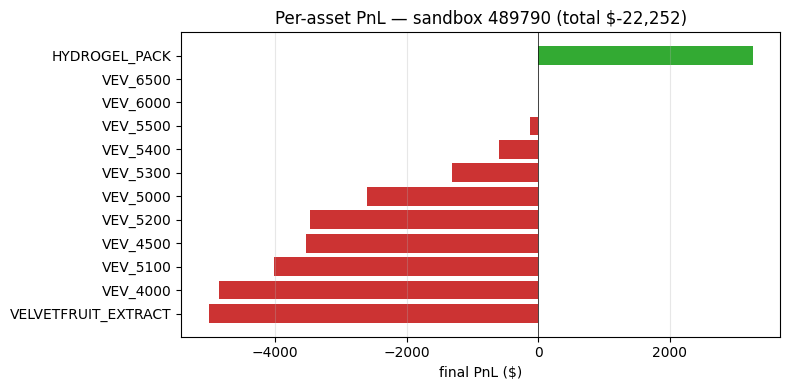

,final_pnl
product,
VELVETFRUIT_EXTRACT,-5012.500000
VEV_4000,-4852.875000
VEV_5100,-4020.546875
VEV_4500,-3527.859375
VEV_5200,-3469.326172
VEV_5000,-2599.992188
VEV_5300,-1308.257812
VEV_5400,-596.593262
VEV_5500,-127.438904


In [7]:
final_pnl = (
    act.groupby('product')
       .apply(lambda d: d.loc[d['timestamp'].idxmax(), 'profit_and_loss'])
       .rename('final_pnl')
       .sort_values()
)
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#cc3333' if v < 0 else '#33aa33' for v in final_pnl.values]
ax.barh(range(len(final_pnl)), final_pnl.values, color=colors)
ax.set_yticks(range(len(final_pnl)))
ax.set_yticklabels(final_pnl.index)
ax.set_xlabel('final PnL ($)')
ax.set_title(f'Per-asset PnL — sandbox {log_id} (total ${final_pnl.sum():,.0f})')
ax.axvline(0, color='black', lw=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()
final_pnl.to_frame()

## 6. PnL trajectory by product over the sandbox window

When does each product start losing? Shows whether the bleed is gradual or concentrated in a few ticks.

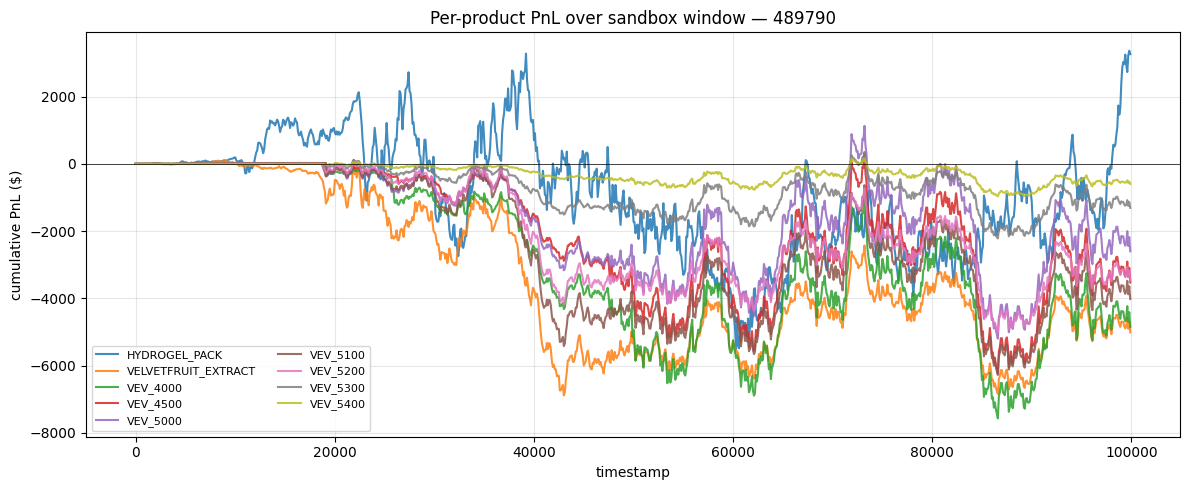

In [8]:
pivot = act.pivot_table(index='timestamp', columns='product', values='profit_and_loss')
fig, ax = plt.subplots(figsize=(12, 5))
for col in pivot.columns:
    if pivot[col].iloc[-1] < -500 or col in (UNDERLYING, 'HYDROGEL_PACK'):
        ax.plot(pivot.index, pivot[col], label=col, alpha=0.85)
ax.legend(loc='best', fontsize=8, ncol=2)
ax.set_xlabel('timestamp')
ax.set_ylabel('cumulative PnL ($)')
ax.axhline(0, color='black', lw=0.5)
ax.grid(alpha=0.3)
ax.set_title(f'Per-product PnL over sandbox window — {log_id}')
plt.tight_layout(); plt.show()

## 7. Spot regime timeline

Reproduce the strategy's regime-detection signal: 200-tick rolling z-score on VFRUIT mid. Mark when |z| ≥ 1.5 (extreme regime, divergence positions are loaded against the upcoming reversion).

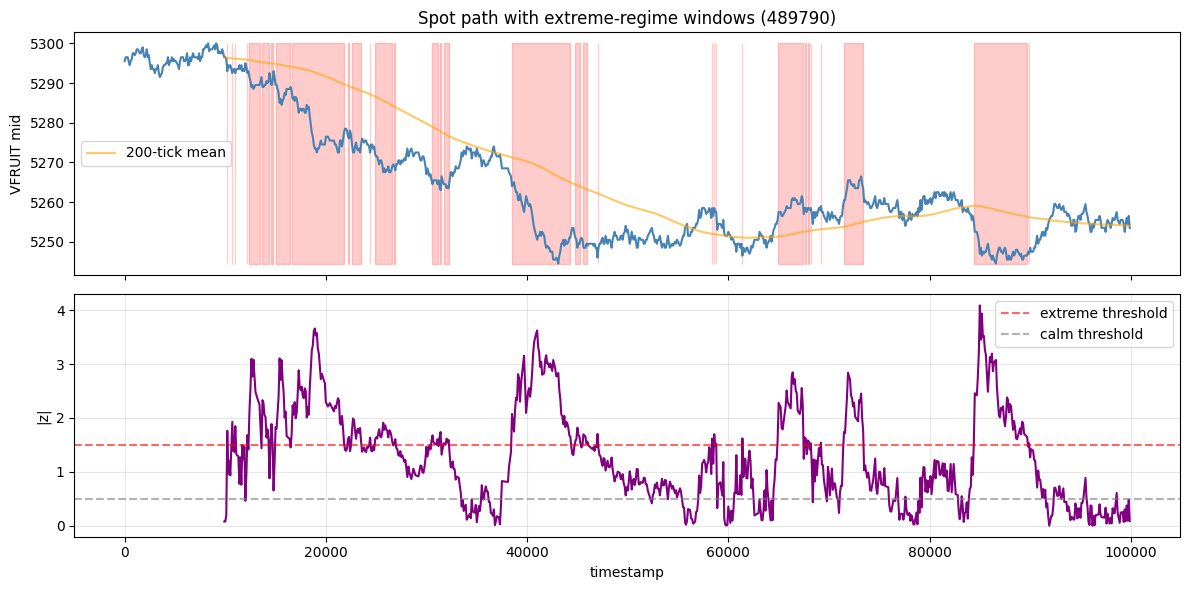

extreme regime fires 32.4% of ticks


In [9]:
spot_log = act[act['product'] == UNDERLYING][['timestamp', 'mid_price']].sort_values('timestamp').reset_index(drop=True)
spot_log['rolling_mu'] = spot_log['mid_price'].rolling(200, min_periods=100).mean()
spot_log['rolling_sd'] = spot_log['mid_price'].rolling(200, min_periods=100).std().clip(lower=0.5)
spot_log['z'] = (spot_log['mid_price'] - spot_log['rolling_mu']).abs() / spot_log['rolling_sd']
spot_log['regime_extreme'] = spot_log['z'] >= 1.5

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(spot_log['timestamp'], spot_log['mid_price'], color='steelblue')
axes[0].plot(spot_log['timestamp'], spot_log['rolling_mu'], color='orange', alpha=0.6, label='200-tick mean')
axes[0].set_ylabel('VFRUIT mid'); axes[0].legend()
axes[0].fill_between(spot_log['timestamp'], spot_log['mid_price'].min(), spot_log['mid_price'].max(),
                     where=spot_log['regime_extreme'].fillna(False), alpha=0.2, color='red')
axes[0].set_title(f'Spot path with extreme-regime windows ({log_id})')
axes[1].plot(spot_log['timestamp'], spot_log['z'], color='purple')
axes[1].axhline(1.5, color='red', linestyle='--', alpha=0.6, label='extreme threshold')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='calm threshold')
axes[1].set_ylabel('|z|'); axes[1].set_xlabel('timestamp'); axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
extreme_pct = 100 * spot_log['regime_extreme'].mean()
print(f'extreme regime fires {extreme_pct:.1f}% of ticks')

## 8. Own-trade timeline (when did we accumulate/unwind?)

Pulls from `tradeHistory`, filters to SUBMISSION-side trades, plots per-product cumulative position.

In [10]:
if len(trh) == 0 or 'buyer' not in trh.columns:
    print(f'tradeHistory is empty in {log_id}.json — skip position plot.')
    print('To get own-trade timelines, re-run the strategy locally and use scripts/extract_run_csv.py:')
    print(f'  cd backtester && cargo run --release -- --trader ../{log_dir.name}/{log_id}.py \\')
    print('    --dataset round4 --day=3 --max-timestamp=99900 --queue-penetration 1.0')
    print(f'  python scripts/extract_run_csv.py backtester/runs/<run-id>')
else:
    own = trh[(trh['buyer'] == 'SUBMISSION') | (trh['seller'] == 'SUBMISSION')].copy()
    own['signed_qty'] = own.apply(
        lambda r: r['quantity'] if r['buyer'] == 'SUBMISSION' else -r['quantity'], axis=1,
    )
    pos = (
        own.groupby(['symbol', 'timestamp'])['signed_qty'].sum()
           .groupby(level=0).cumsum().reset_index()
           .rename(columns={'signed_qty': 'position'})
    )
    interesting = [s for s in pos['symbol'].unique()
                   if s in (UNDERLYING, 'HYDROGEL_PACK') or s in STRIKES]
    fig, ax = plt.subplots(figsize=(12, 5))
    for s in sorted(interesting):
        sub = pos[pos['symbol'] == s]
        if len(sub) > 5:
            ax.plot(sub['timestamp'], sub['position'], label=s, alpha=0.85)
    ax.legend(loc='best', fontsize=8, ncol=2)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xlabel('timestamp'); ax.set_ylabel('signed position')
    ax.set_title(f'Own position by product — {log_id}')
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

tradeHistory is empty in 489790.json — skip position plot.
To get own-trade timelines, re-run the strategy locally and use scripts/extract_run_csv.py:
  cd backtester && cargo run --release -- --trader ../489790/489790.py \
    --dataset round4 --day=3 --max-timestamp=99900 --queue-penetration 1.0
  python scripts/extract_run_csv.py backtester/runs/<run-id>


## 9. Save tick-level voucher CSV (used by tuning scripts)

Writes `notebooks/round4_voucher_ticks.csv` — one row per (day, timestamp, product) with mid + intrinsic + TV. Used by `voucher_diagnostics.py`-style scripts.

In [11]:
out = vev[['day', 'timestamp', 'product', 'strike', 'spot', 'mid_price', 'intrinsic', 'tv']].copy()
out_path = REPO / 'notebooks' / 'round4_voucher_ticks.csv'
out.to_csv(out_path, index=False)
print(f'wrote {out_path}  ({len(out)} rows)')

wrote /Users/kimbap/Code/projects/slu-imc-prosperity-4/notebooks/round4_voucher_ticks.csv  (300000 rows)
